In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [3]:
import os

for root, dirs, files in os.walk("/kaggle/input"):
    print(root)

/kaggle/input
/kaggle/input/datasets
/kaggle/input/datasets/niyarrbarman
/kaggle/input/datasets/niyarrbarman/landslide-divided
/kaggle/input/datasets/niyarrbarman/landslide-divided/dataset
/kaggle/input/datasets/niyarrbarman/landslide-divided/dataset/validation
/kaggle/input/datasets/niyarrbarman/landslide-divided/dataset/validation/images
/kaggle/input/datasets/niyarrbarman/landslide-divided/dataset/validation/masks
/kaggle/input/datasets/niyarrbarman/landslide-divided/dataset/test
/kaggle/input/datasets/niyarrbarman/landslide-divided/dataset/test/images
/kaggle/input/datasets/niyarrbarman/landslide-divided/dataset/test/masks
/kaggle/input/datasets/niyarrbarman/landslide-divided/dataset/train
/kaggle/input/datasets/niyarrbarman/landslide-divided/dataset/train/images
/kaggle/input/datasets/niyarrbarman/landslide-divided/dataset/train/masks


In [4]:
# ================================
# 📦 Step 1: Imports & Setup
# ================================
import os
import numpy as np
import cv2
import matplotlib.pyplot as plt
from glob import glob
from sklearn.model_selection import train_test_split
from sklearn.metrics import (classification_report, confusion_matrix,
                             precision_score, recall_score, f1_score,
                             accuracy_score, jaccard_score)

import seaborn as sns
import tensorflow as tf
from tensorflow.keras.utils import Sequence
from tensorflow.keras.layers import (Conv2D, MaxPooling2D, Conv2DTranspose, 
                                     concatenate, Input, Add, BatchNormalization, Activation)
from tensorflow.keras.layers import LayerNormalization, Dense, Reshape, GlobalAveragePooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

# ⚙️ Config
IMAGE_SIZE = 256
BATCH_SIZE = 8
EPOCHS = 25

2026-03-27 17:37:24.996512: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1774633045.217345      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1774633045.281016      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1774633045.789032      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774633045.789069      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774633045.789072      55 computation_placer.cc:177] computation placer alr

In [5]:
# ================================
# 📦 Step 2: Dataset Paths
# ================================
train_image_path = "/kaggle/input/datasets/niyarrbarman/landslide-divided/dataset/train/images"
train_mask_path = "/kaggle/input/datasets/niyarrbarman/landslide-divided/dataset/train/masks"
val_image_path = "/kaggle/input/datasets/niyarrbarman/landslide-divided/dataset/validation/images"
val_mask_path = "/kaggle/input/datasets/niyarrbarman/landslide-divided/dataset/validation/masks"
test_image_path = "/kaggle/input/datasets/niyarrbarman/landslide-divided/dataset/test/images"
test_mask_path = "/kaggle/input/datasets/niyarrbarman/landslide-divided/dataset/test/masks"


In [6]:
# ================================
# 📦 Step 3: Preprocessing Functions
# ================================
def read_image(path):
    image = cv2.imread(path, cv2.IMREAD_COLOR)
    image = cv2.resize(image, (IMAGE_SIZE, IMAGE_SIZE))
    image = image / 255.0
    return image

def read_mask(path):
    mask = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    mask = cv2.resize(mask, (IMAGE_SIZE, IMAGE_SIZE))
    mask = np.expand_dims(mask, axis=-1)
    mask = mask / 255.0
    return mask


In [7]:
# ================================
# 📦 Step 4: Data Generator (FIXED)
# ================================
class DataGenerator(Sequence):
    def __init__(self, image_paths, mask_paths, batch_size=BATCH_SIZE, shuffle=True):
        super().__init__()
        self.image_paths = image_paths
        self.mask_paths = mask_paths
        self.batch_size = batch_size
        self.shuffle = shuffle
        self.on_epoch_end()

    def __len__(self):
        return int(np.ceil(len(self.image_paths) / self.batch_size))  # ✅ FIXED

    def on_epoch_end(self):
        self.indices = np.arange(len(self.image_paths))
        if self.shuffle:
            np.random.shuffle(self.indices)

    def __getitem__(self, index):
        indices = self.indices[index * self.batch_size:(index + 1) * self.batch_size]
        batch_images = [read_image(self.image_paths[i]) for i in indices]
        batch_masks = [read_mask(self.mask_paths[i]) for i in indices]
        return np.array(batch_images), np.array(batch_masks)

In [8]:
# ================================
# 📦 Step 5: SegFormer Model (FIXED)
# ================================

def transformer_block(x, num_heads=4, key_dim=64):
    attn = tf.keras.layers.MultiHeadAttention(num_heads=num_heads, key_dim=key_dim)(x, x)
    x = Add()([x, attn])
    x = LayerNormalization()(x)

    ffn = Dense(key_dim * 2, activation="relu")(x)
    ffn = Dense(key_dim)(ffn)
    x = Add()([x, ffn])
    x = LayerNormalization()(x)

    return x


def build_segformer(input_shape=(IMAGE_SIZE, IMAGE_SIZE, 3)):
    inputs = Input(shape=input_shape)

    # Patch embedding
    x = Conv2D(64, 7, strides=4, padding='same')(inputs)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)

    h, w, c = x.shape[1], x.shape[2], x.shape[3]

    # Flatten
    x = Reshape((h * w, c))(x)

    # Transformer encoder
    for _ in range(4):
        x = transformer_block(x)

    # Reshape back
    x = Reshape((h, w, c))(x)

    # Decoder
    # Decoder (FIXED)
    x = Conv2DTranspose(128, 3, strides=2, padding='same')(x)  # 64 → 128
    x = BatchNormalization()(x)
    x = Activation('relu')(x)

    x = Conv2DTranspose(64, 3, strides=2, padding='same')(x)   # 128 → 256
    x = BatchNormalization()(x)
    x = Activation('relu')(x)

    outputs = Conv2D(1, 1, activation='sigmoid')(x)

    return Model(inputs, outputs, name="SegFormer")  # ✅ IMPORTANT

In [9]:
# ================================
# 📦 Step 6: Load Dataset
# ================================
train_images = sorted(glob(os.path.join(train_image_path + "/*")))
train_masks = sorted(glob(os.path.join(train_mask_path + "/*")))
val_images = sorted(glob(os.path.join(val_image_path + "/*")))
val_masks = sorted(glob(os.path.join(val_mask_path + "/*")))

train_gen = DataGenerator(train_images, train_masks)
val_gen = DataGenerator(val_images, val_masks)

In [10]:
print("Train images:", len(train_images))
print("Val images:", len(val_images))

Train images: 1385
Val images: 396


In [11]:
# ================================
# 📦 Step 7: Compile & Train
# ================================
model = build_segformer()
model.compile(optimizer=Adam(1e-4), loss="binary_crossentropy", metrics=["accuracy"])

callbacks = [
    tf.keras.callbacks.ModelCheckpoint("model.keras", save_best_only=True, verbose=1),
    tf.keras.callbacks.ReduceLROnPlateau(patience=3, verbose=1),
    tf.keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True, verbose=1)
]

history = model.fit(train_gen, validation_data=val_gen, epochs=EPOCHS, callbacks=callbacks)


I0000 00:00:1774633508.825710      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1774633508.831552      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Epoch 1/25


I0000 00:00:1774633520.616768     129 service.cc:152] XLA service 0x7862b0098a90 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1774633520.616804     129 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1774633520.616808     129 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1774633522.635979     129 cuda_dnn.cc:529] Loaded cuDNN version 91002
2026-03-27 17:45:24.712000: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-27 17:45:24.923747: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
I0000 00:00:1774633537.071524     129 device_co

 98/174 ━━━━━━━━━━━━━━━━━━━━ 1:12 956ms/step - accuracy: 0.6483 - loss: 0.6410

2026-03-27 17:47:13.704466: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-27 17:47:13.907499: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-27 17:47:14.180556: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-27 17:47:14.384957: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


174/174 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.7359 - loss: 0.5433

2026-03-27 17:49:11.998382: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-27 17:49:12.230763: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-27 17:49:12.553930: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-27 17:49:12.783573: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.



Epoch 1: val_loss improved from inf to 0.36146, saving model to model.keras
174/174 ━━━━━━━━━━━━━━━━━━━━ 246s 1s/step - accuracy: 0.7366 - loss: 0.5424 - val_accuracy: 0.9495 - val_loss: 0.3615 - learning_rate: 1.0000e-04
Epoch 2/25
174/174 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9486 - loss: 0.2132
Epoch 2: val_loss improved from 0.36146 to 0.20984, saving model to model.keras
174/174 ━━━━━━━━━━━━━━━━━━━━ 224s 1s/step - accuracy: 0.9486 - loss: 0.2131 - val_accuracy: 0.9493 - val_loss: 0.2098 - learning_rate: 1.0000e-04
Epoch 3/25
174/174 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9506 - loss: 0.1593
Epoch 3: val_loss improved from 0.20984 to 0.13974, saving model to model.keras
174/174 ━━━━━━━━━━━━━━━━━━━━ 223s 1s/step - accuracy: 0.9506 - loss: 0.1593 - val_accuracy: 0.9549 - val_loss: 0.1397 - learning_rate: 1.0000e-04
Epoch 4/25
174/174 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9471 - loss: 0.1433
Epoch 4: val_loss improved from 0.13974 to 0.12721, saving model to mo

In [12]:
model.summary()

Model: "SegFormer"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 64, 64,    │      9,472 │ input_layer[0][0] │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 64, 64,    │        256 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 64, 64,    │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape (Reshape)   │ (None, 4096, 64)  │          0 │ activation[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 4096, 64)  │     66,368 │ reshape[0][0],    │
│ (MultiHeadAttentio… │                   │            │ reshape[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 4096, 64)  │          0 │ reshape[0][0],    │
│                     │                   │            │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 4096, 64)  │        128 │ add[0][0]         │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 4096, 128) │      8,320 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 4096, 64)  │      8,256 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 4096, 64)  │          0 │ layer_normalizat… │
│                     │                   │            │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 4096, 64)  │        128 │ add_1[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 4096, 64)  │     66,368 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_2 (Add)         │ (None, 4096, 64)  │          0 │ layer_normalizat… │
│                     │                   │            │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 4096, 64)  │        128 │ add_2[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 4096, 128) │      8,320 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 4096, 64)  │      8,256 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_3 (Add)         │ (None, 4096, 64)  │          0 │ layer_normalizat… │
│                     │                   │            │ dense_3[0][0]     │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 1,472,005 (5.62 MB)

 Trainable params: 490,497 (1.87 MB)

 Non-trainable params: 512 (2.00 KB)

 Optimizer params: 980,996 (3.74 MB)

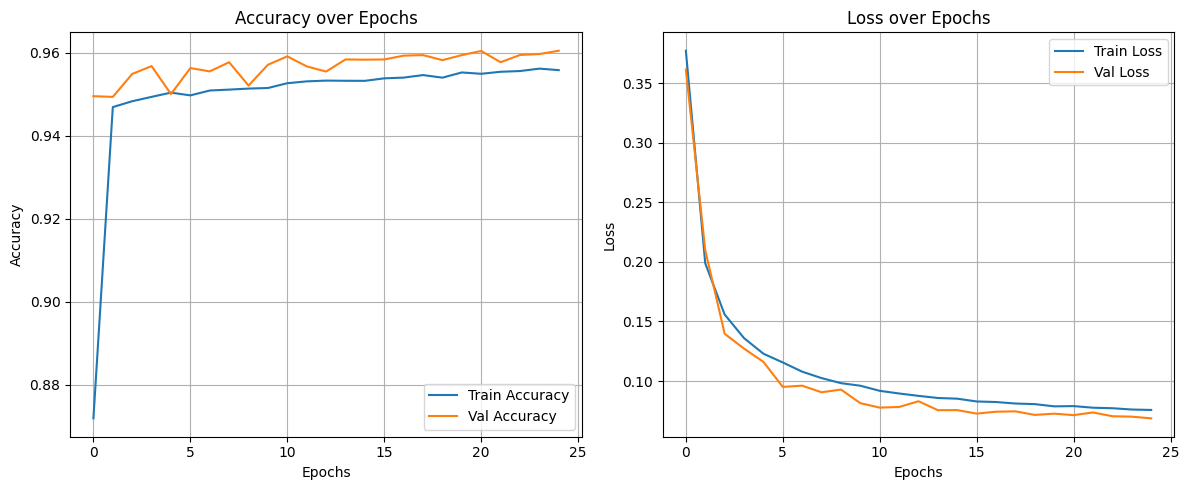

In [13]:
# ================================
# 📊 Step 8: Training Graphs
# ================================
plt.figure(figsize=(12, 5))

# Accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history["accuracy"], label="Train Accuracy")
plt.plot(history.history["val_accuracy"], label="Val Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Accuracy over Epochs")
plt.legend()
plt.grid()

# Loss
plt.subplot(1, 2, 2)
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Val Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Loss over Epochs")
plt.legend()
plt.grid()

plt.tight_layout()
plt.show()


In [14]:
# ================================
# 📊 Step 9: Training & Testing Results
# ================================
test_images = sorted(glob(os.path.join(test_image_path, "*.png")))
test_masks = sorted(glob(os.path.join(test_mask_path, "*.png")))
test_gen = DataGenerator(test_images, test_masks, shuffle=False)

# Evaluate
train_loss, train_acc = model.evaluate(train_gen, verbose=0)
test_loss, test_acc = model.evaluate(test_gen, verbose=0)

print(f"✅ Final Training Accuracy: {train_acc*100:.2f}%")
print(f"✅ Final Testing Accuracy : {test_acc*100:.2f}%")


2026-03-27 19:20:28.332944: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-27 19:20:28.565468: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-27 19:20:28.896797: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-27 19:20:29.128975: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


✅ Final Training Accuracy: 95.61%
✅ Final Testing Accuracy : 95.35%


In [15]:
# ================================
# 📊 Step 10: Classification Metrics
# ================================
y_true, y_pred = [], []

for i in range(len(test_gen)):
    X_batch, Y_batch = test_gen[i]
    preds = model.predict(X_batch)
    preds = (preds > 0.5).astype(np.uint8).flatten()
    Y_batch = (Y_batch > 0.5).astype(np.uint8).flatten()
    y_pred.extend(preds)
    y_true.extend(Y_batch)

y_true = np.array(y_true)
y_pred = np.array(y_pred)

print("\n📊 Classification Report:")
print(classification_report(y_true, y_pred, target_names=["No Landslide", "Landslide"]))

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 429ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 432ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 424ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 431ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 425ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 429ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 435ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 433ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 432ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 435ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 433ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 435ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 438ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 437ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 439ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 442ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 438ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 443ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 443ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 445ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 440ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 449ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 449ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step

📊 Classification Report:
     

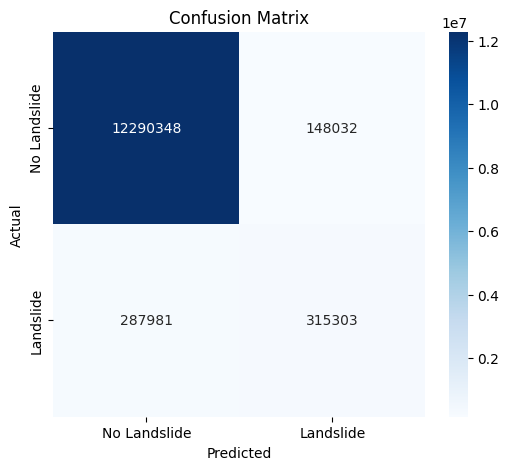

In [16]:
# ================================
# 📊 Step 11: Confusion Matrix
# ================================
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=["No Landslide", "Landslide"],
            yticklabels=["No Landslide", "Landslide"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()


In [17]:
# ================================
# 📊 Step 12: Additional Metrics
# ================================
def dice_coef(y_true, y_pred):
    intersection = np.sum(y_true * y_pred)
    return (2. * intersection) / (np.sum(y_true) + np.sum(y_pred) + 1e-7)

accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred)
recall = recall_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)
iou = jaccard_score(y_true, y_pred)
dice = dice_coef(y_true, y_pred)

print("\n📈 Pixel-wise Evaluation Metrics:")
print(f"Accuracy        : {accuracy:.4f}")
print(f"Precision       : {precision:.4f}")
print(f"Recall          : {recall:.4f}")
print(f"F1 Score        : {f1:.4f}")
print(f"IoU Score       : {iou:.4f}")
print(f"Dice Coefficient: {dice:.4f}")



📈 Pixel-wise Evaluation Metrics:
Accuracy        : 0.9666
Precision       : 0.6805
Recall          : 0.5226
F1 Score        : 0.5912
IoU Score       : 0.4197
Dice Coefficient: 0.5912


In [18]:
def calculate_area(mask):
    return np.sum(mask == 1)

def classify_severity(area):
    if area < 5000:
        return "Low"
    elif area < 20000:
        return "Medium"
    else:
        return "High"

def generate_heatmap(image, mask):
    heatmap = np.zeros_like(image)
    heatmap[:, :, 0] = mask.squeeze() * 255

    overlay = cv2.addWeighted(image.astype(np.float32), 0.7,
                              heatmap.astype(np.float32), 0.3, 0)
    return overlay

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 881ms/step


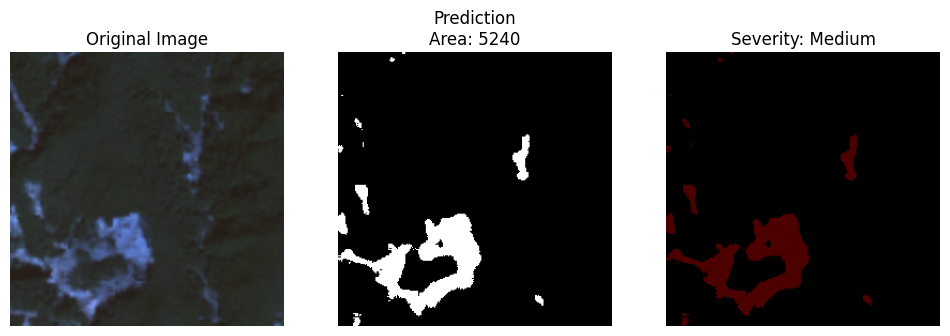

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step


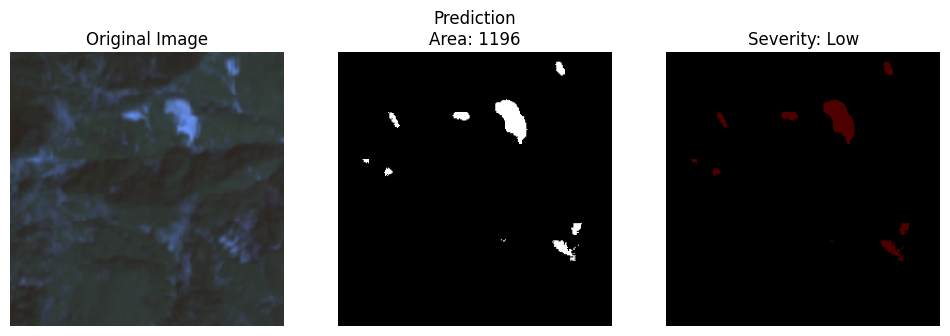

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step


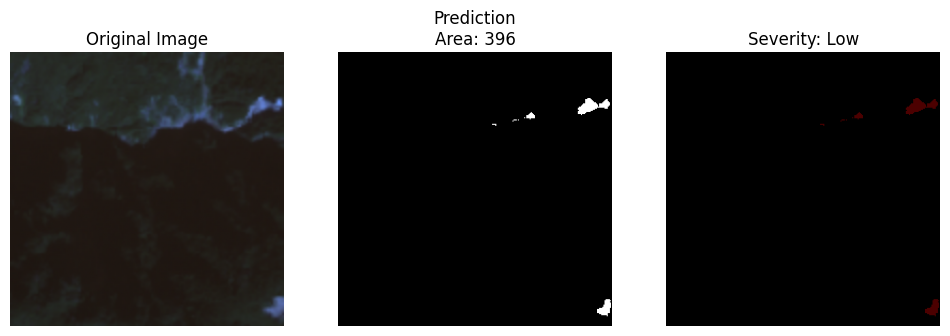

In [19]:
# ================================
# 🔍 Apply on Test Data
# ================================
for i in range(3):   # show 3 samples
    img = read_image(test_images[i])
    mask = read_mask(test_masks[i])

    pred = model.predict(np.expand_dims(img, axis=0))[0]
    pred = (pred > 0.5).astype(np.uint8)

    # Area
    area = calculate_area(pred)

    # Severity
    severity = classify_severity(area)

    # Heatmap
    heatmap = generate_heatmap(img, pred)

    # -------------------------------
    # Display
    # -------------------------------
    plt.figure(figsize=(12, 4))

    plt.subplot(1, 3, 1)
    plt.title("Original Image")
    plt.imshow(img)
    plt.axis("off")

    plt.subplot(1, 3, 2)
    plt.title(f"Prediction\nArea: {area}")
    plt.imshow(pred.squeeze(), cmap='gray')
    plt.axis("off")

    plt.subplot(1, 3, 3)
    plt.title(f"Severity: {severity}")
    plt.imshow(heatmap.astype(np.uint8))
    plt.axis("off")

    plt.show()